In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

import hw3helper

warnings.filterwarnings("ignore")

In [2]:
sb_hist = pd.read_csv("sb_history.csv", index_col=["Date"], parse_dates=["Date"])
sb_test = pd.read_csv("sb_test.csv", index_col=["Date"], parse_dates=["Date"])

In [3]:
p_values: list[int] = [0, 1, 2, 3]
d_values: list[int] = [0, 1, 2, 3]
q_values: list[int] = [0, 1, 2, 3]
trend_values: list[str | list[int]] = ["n", [1, 1, 1, 1]]
best_cfg, best_trend = hw3helper.evaluate_arima_models(
    sb_hist.to_numpy(), 0.8, p_values, d_values, q_values, trend_values
)
p, d, q = best_cfg
model = ARIMA(sb_hist, order=(p, d, q), trend=best_trend)
results = model.fit()

print("\n")
print(f"Best ARIMA{best_cfg} with trend {best_trend}")
preds = results.forecast(steps=len(sb_test))
print("predictions:")
print(preds)

print("\n")
rmse = np.sqrt(mean_squared_error(sb_test["Adj Close"].values, preds))
print(f"Test RMSE: {rmse}")



Best ARIMA(2, 3, 1) with trend n
predictions:
130    16.502476
131    16.987521
132    17.530255
133    18.077139
134    18.613019
135    19.161041
136    19.710302
137    20.261900
138    20.817886
139    21.376679
140    21.938768
141    22.504240
Name: predicted_mean, dtype: float64


Test RMSE: 3.02184225072473


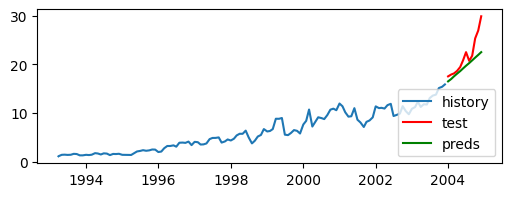

In [4]:
fig, ax = plt.subplots(figsize=(6, 2))
ax.plot(sb_hist.index, sb_hist["Adj Close"], label="history")
ax.plot(sb_test.index, sb_test["Adj Close"], label="test", color="red")
ax.plot(sb_test.index, preds, label="preds", color="green")
ax.legend(loc="lower right")
plt.show()

In [5]:
X_train = sb_hist.to_numpy()[: int(len(sb_hist) * 0.8)]
X_test = sb_hist.to_numpy()[int(len(sb_hist) * 0.8) :]
best_model_results = hw3helper.find_best_arima_model(
    X_train, X_test, p_values, d_values, q_values, trend_values
)

print(best_model_results.__str__())

# build a new model using the p d q and trend from the best model found
model = best_model_results.train_model(sb_hist.to_numpy())
# make predictions

mypreds = model.forecast(steps=len(sb_test))

ARIMA(2, 3, 1) with trend n has RMSE: 1.6559861883921072


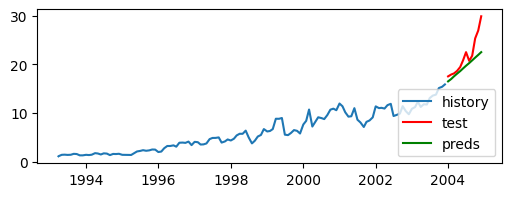

In [6]:
fig, ax = plt.subplots(figsize=(6, 2))
ax.plot(sb_hist.index, sb_hist["Adj Close"], label="history")
ax.plot(sb_test.index, sb_test["Adj Close"], label="test", color="red")
ax.plot(sb_test.index, mypreds, label="preds", color="green")
ax.legend(loc="lower right")
plt.show()

2. SARIMA

In [7]:
beer_df = pd.read_csv("beer.csv", index_col="Date", parse_dates=["Date"])

beer_train = beer_df[beer_df.index <= "2015-11-30"]
beer_test = beer_df[beer_df.index > "2015-11-30"]
# assert not empty
assert len(beer_train) > 0
assert len(beer_test) > 0


beer_train_consuption = beer_train["Beer_Consumption"]
beer_test_consuption = beer_test["Beer_Consumption"]

p_values: list[int] = [0, 1, 2]
d_values: list[int] = [0, 1, 2]
q_values: list[int] = [0, 1, 2]

P_values = [0, 1]
D_values = [1]
Q_values = [0, 1]

seasonal_period = 7

trend_values: list[str | list[int]] = ["n", [1, 1, 1, 1], "t", "ct"]

beer_train_split_train = beer_train_consuption[: int(len(beer_train_consuption) * 0.8)]
beer_train_split_test = beer_train_consuption[int(len(beer_train_consuption) * 0.8) :]
beer_res = hw3helper.find_best_sarima_model(
    beer_train_split_train.to_numpy(),
    beer_train_split_test.to_numpy(),
    p_values,
    d_values,
    q_values,
    P_values,
    D_values,
    Q_values,
    seasonal_period,
    trend_values,
)

# fit on entire training data and predict on test data
model = beer_res.train_model(beer_train_consuption.to_numpy(), 12)
beer_preds = model.forecast(steps=len(beer_test_consuption))
beer_rmse = np.sqrt(mean_squared_error(beer_test_consuption.to_numpy(), beer_preds))
print(f"Test RMSE: {beer_rmse}")

print(beer_res.__str__())


Test RMSE: 3.771026316346365
SARIMA(2, 1, 1) x (0, 1, 1, 7) with trend n has RMSE: 3.902586345725491


In [8]:
print(beer_res.__str__())


SARIMA(2, 1, 1) x (0, 1, 1, 7) with trend n has RMSE: 3.902586345725491
